Вот подробное решение вашего задания по вычислительной математике, охватывающее этапы до численного решения.Система уравнений задана в виде $\frac{\partial u}{\partial t}+A\frac{\partial u}{\partial x}=0$, поскольку вектор правой части $b(x)$ нулевой.Шаг 1: Поиск собственных значений матрицы AДля приведения системы к характеристическому виду необходимо найти собственные значения $\lambda$ матрицы $A$. Решим характеристическое уравнение $\det(A - \lambda I) = 0$:$$\begin{vmatrix} 9-\lambda & -4 & -8 \\ -2 & 7-\lambda & -8 \\ 2 & 2 & 17-\lambda \end{vmatrix} = 0$$

Таким образом, собственные значения матрицы:

$\lambda_1 = 9$ 

$\lambda_2 = 11$

$\lambda_3 = 13$

Все собственные значения действительные и различные, значит, система является строго гиперболической.

Шаг 2: Поиск левых собственных векторов

Левые собственные векторы $l_i$ находятся из уравнения $A^T l_i = \lambda_i l_i$, где $A^T$ — транспонированная матрица:

$$A^T = \begin{pmatrix} 9 & -2 & 2 \\ -4 & 7 & 2 \\ -8 & -8 & 17 \end{pmatrix}$$

Шаг 3: Приведение к характеристическому видуСоставим матрицу перехода $S^{-1}$, строками которой являются левые собственные векторы:

$$S^{-1} = \begin{pmatrix} 0 & 1 & 1 \\ 1 & -1 & 0 \\ 1 & 0 & 2 \end{pmatrix}$$

Умножив исходную систему $\frac{\partial u}{\partial t}+A\frac{\partial u}{\partial x}=0$ слева на $S^{-1}$, мы получим систему независимых уравнений переноса (инвариантов Римана $w = S^{-1}u$):

$$w = S^{-1}u = \begin{pmatrix} 0 & 1 & 1 \\ 1 & -1 & 0 \\ 1 & 0 & 2 \end{pmatrix} \begin{pmatrix} u_1 \\ u_2 \\ u_3 \end{pmatrix} = \begin{pmatrix} u_2 + u_3 \\ u_1 - u_2 \\ u_1 + 2u_3 \end{pmatrix}$$

Система в характеристическом виде записывается как $\frac{\partial w}{\partial t} + \Lambda \frac{\partial w}{\partial x} = 0$, где $\Lambda = \text{diag}(9, 11, 13)$:

$$\frac{\partial (u_2 + u_3)}{\partial t} + 9 \frac{\partial (u_2 + u_3)}{\partial x} = 0$$

$$\frac{\partial (u_1 - u_2)}{\partial t} + 11 \frac{\partial (u_1 - u_2)}{\partial x} = 0$$
$$\frac{\partial (u_1 + 2u_3)}{\partial t} + 13 \frac{\partial (u_1 + 2u_3)}{\partial x} = 0$$

In [34]:
import numpy as np


L = 1.0
T = 1.0
# Собственные значения (из характеристического уравнения)
lambdas = np.array([9.0, 11.0, 13.0])

# Матрицы перехода
S_inv = np.array([[0, 1, 1], [1, -1, 0], [1, 0, 2]])

S = np.array([[2, 2, -1], [2, 1, -1], [-1, -1, 1]])


# Численное решение (скалярного уравнения)
def scalar(M_, N_, i, W_, scheme):
    tau_ = T / N_
    h_ = L / M_
    sigma = lambdas[i] * tau_ / h_
    for m in range(1, M_ + 1):
        W_[i, 1, m] = (W_[i, 0, m] + sigma * W_[i, 1, m - 1]) / (1 + sigma)

    for n in range(1, N_):
        # Идем по пространству слева направо

        for m in range(1, M_ + 1):
            if scheme == 1:
                W_[i, n + 1, m] = (W_[i, n, m] + sigma * W_[i, n + 1, m - 1]) / (
                    1 + sigma
                )
            elif scheme == 2:
                W_[i, n + 1, m] = (
                    W_[i, n, m]
                    - (W_[i, n, m - 1] - W_[i, n - 1, m - 1])
                    - 2 * sigma * (W_[i, n, m] - W_[i, n, m - 1])
                )
    return W_


# Для вектора
def vect(M_, N_, W_, scheme):
    for i in range(3):
        W_ = scalar(M_, N_, i, W_, scheme)
    return W_


def ful(M_, N_, scheme):
    x = np.linspace(0, L, M_ + 1)
    # t = np.linspace(0, T, N_ + 1)

    # Начальные условия для u(x, 0)
    u = np.zeros((3, N_ + 1, M_ + 1))
    u[0, 0, :] = x**3
    u[1, 0, :] = 1 - x**2
    u[2, 0, :] = x**2 + 1

    # Граничные условия
    u[0, :, 0] = u[0, 0, 0]
    u[1, :, 0] = u[1, 0, 0]
    u[2, :, 0] = u[2, 0, 0]

    # Переход от u к w
    w = np.zeros((3, N_ + 1, M_ + 1))
    for n in range(N_ + 1):
        for m in range(M_ + 1):
            w[:, n, m] = S_inv @ u[:, n, m]

    w = vect(M_, N_, w, scheme)

    # Возврат к исходным переменным u
    u = np.zeros((3, N_ + 1, M_ + 1))
    for n in range(N_ + 1):
        for m in range(M_ + 1):
            u[:, n, m] = S @ w[:, n, m]

    return u

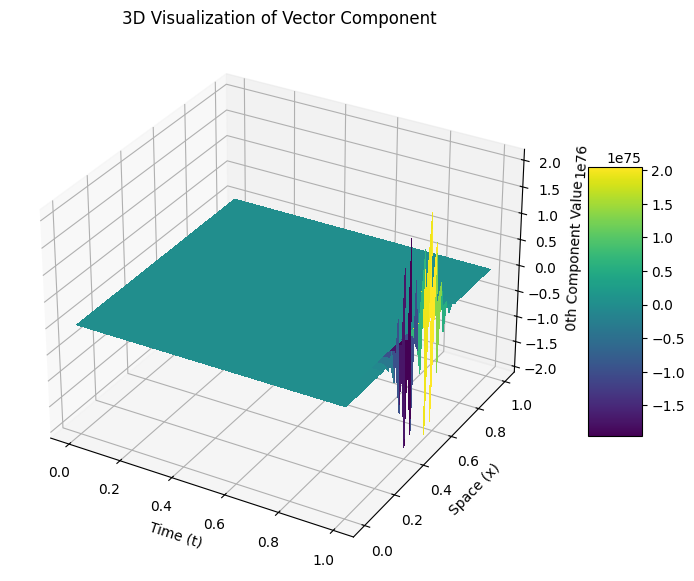

In [35]:
import matplotlib.pyplot as plt
from matplotlib import cm

def draw(M_, N_, scheme, index):

    # 2. Define your axes
    t = np.linspace(0, T, N_ + 1)  # Time axis
    x = np.linspace(0, L, M_ + 1)  # Space axis
    Time, X = np.meshgrid(t, x)  # Create the 2D grid

    # 3. Extract the 0th component
    # We transpose (.T) because meshgrid expects (Y, X) shape for the Z input
    u_res = ful(M_, N_, scheme)
    Z = u_res[index, :, :].T

    # 4. Plotting
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 7))

    surf = ax.plot_surface(Time, X, Z, cmap=cm.viridis, linewidth=0, antialiased=False)

    # Labels and formatting
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("Space (x)")
    ax.set_zlabel(f"{index}th Component Value")
    ax.set_title("3D Visualization of Vector Component")

    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


draw(50, 50, 2, 0)